In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/my_DeepLearning'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/my_DeepLearning.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/my_DeepLearning
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/my_DeepLearning/9
    print("準備完了！このまま下のセルを実行できます。")

# 第9章 正則化 (Regularization)
## 9.4 パラメータ共有 (Parameter Sharing)

本ノートブックは、Christopher M. Bishop & Hugh Bishop (2024)『深層学習：基礎と概念 (Deep Learning: Foundations and Concepts)』第9章「正則化」第9.4節「パラメータ共有 (Parameter Sharing)」の理論的背景、数学的導出、再利用可能な共通モジュール実装、および可視化プロットを提供します。

---

### 目次
1. **9.4 パラメータ共有の基本原理 (Parameter Sharing)**
   - ハードパラメータ共有 (Hard Parameter Sharing) と畳み込みニューラルネットワーク (CNN)
   - 対称性（Symmetry）と帰納バイアス（Inductive Bias）
   - ハード制約の限界とソフト制約への動機付け
2. **9.4.1 ソフト重み共有 (Soft Weight Sharing: Nowlan & Hinton, 1992)**
   - 単一ゼロ平均ガウス（Weight Decay）から混合ガウス分布（GMM）への拡張
   - GMM事前分布 $p(\mathbf{w})$ と正則化項 $\Omega(\mathbf{w})$ の定義 (式 9.21 - 9.23)
   - ベイズの定理による負担率（事後確率） $\gamma_j(w_i)$ の導出 (式 9.24 / 演習 9.8)
   - 重み勾配 $\frac{\partial \widetilde{E}}{\partial w_i}$ とバネの復元力解釈 (式 9.25 / 演習 9.9)
   - 中心パラメータ $\mu_j$ の勾配と事後加重平均 (式 9.26 / 演習 9.10)
   - 分散の再パラメータ化 $\sigma_j^2 = \exp(\beta_j)$ と対数分散勾配 (式 9.27 - 9.28 / 演習 9.11)
   - 混合係数のソフトマックス表現 $\pi_j$ とロジット勾配 (式 9.29 - 9.31 / 演習 9.12)
3. **数値検証と可視化**
   - 解析的勾配 vs 有限差分（数値微分）の厳密な一致検証
   - 図版可視化 1: GMM事前分布 $p(w)$、ポテンシャルエネルギー $\Omega(w)$、復元力場 $-\frac{\partial \Omega}{\partial w}$
   - 図版可視化 2: MLP学習における重みクラスタリングの動的進化過程
   - 図版可視化 3: 正則化なし / $L_2$ Weight Decay / Soft Weight Sharing / Hard Weight Sharing の包括的比較
4. **発展トピック**
   - 生成モデルと識別モデルのハイブリッド結合 (Lasserre, Bishop, and Minka, 2006)
5. **まとめと第9.5節（残差結合: Residual Connections）への展望**


## 1. 9.4 パラメータ共有の基本原理 (Parameter Sharing)

過剰適合を抑え汎化性能を最大化するための最も直感的かつ強力な帰納バイアスの一つが**パラメータ共有 (Parameter Sharing)** です。
ネットワーク内の複数の結合において同一の重みパラメータを共有（拘束）することで、以下の重要な利点が生じます：

1. **有効パラメータ数の削減**:
   モデル全体の結合数が多くても、独立なパラメータ数が劇的に減少するため、統計的自由度が下がり過学習を防ぎます。
2. **事前知識・対称性の埋め込み**:
   例えば画像処理における**並進等分散性（Translation Equivariance）**は、「画像のどの位置にあっても同じ局所特徴抽出器（フィルタ）を適用すべき」という強い対称性を持ちます。畳み込みニューラルネットワーク（CNN: 第10章）では、空間全体でカーネル重みを共有することで、この対称性をモデル構造として直接担保しています。
3. **ハードパラメータ共有の限界**:
   しかし、厳密な等号制約（Hard Parameter Sharing）は、「どの重みとどの重みが等しくなるべきか」という制約の形式を**人間が事前に完全に特定できる特定の問題**にしか適用できません。
   任意の問題において、重みが自動的にグループ化され、各グループの代表値に集約されるような、より柔軟な手法が求められます。


## 2. 9.4.1 ソフト重み共有 (Soft Weight Sharing)

ハードな等号制約に代わり、**Nowlan & Hinton (1992)** は重みのグループが「似たような値」を持つことを促す**ソフト重み共有 (Soft Weight Sharing)** を提唱しました。

この手法では、重みをいくつのグループに分けるか、各グループの平均値 $\mu_j$、グループ内のばらつき $\sigma_j^2$、各グループの混合比率 $\pi_j$ のすべてが、**学習アルゴリズムによって自律的に決定**されます。

### 単一ガウス事前分布（Weight Decay）からの自然な拡張
前節 9.2節で導出した通常の重み減衰（$L_2$ 正則化）は、各重み $w_i$ が平均 $0$、共通分散 $\sigma^2$ の単一ガウス分布に従うという事前分布の負の対数尤度とみなすことができます：
$$
p(w_i) = \mathcal{N}(w_i | 0, \sigma^2) \implies \Omega(\mathbf{w}) = \frac{1}{2\sigma^2} \sum_i w_i^2 + \text{const}
$$
この事前分布は、すべての重みをただ一つの値（$w=0$）へと収縮させます。

ソフト重み共有では、重みがゼロだけでなく**複数の異なる代表値（クラスター中心）**の周りに集まることを促すため、事前分布として**混合ガウス分布 (Gaussian Mixture Model: GMM)** を採用します。


### 数式導出ステップ (1): GMM事前分布と正則化誤差関数 (式 9.21 - 9.23)

重みベクトル $\mathbf{w} = (w_1, \dots, w_W)^\top$ に対する事前確率密度 $p(\mathbf{w})$ を、$K$ 個のガウス成分の混合分布として定式化します：

$$\begin{aligned}
p(\mathbf{w}) = \prod_{i=1}^W \left\{ \sum_{j=1}^K \pi_j \mathcal{N}(w_i | \mu_j, \sigma_j^2) \right\} \quad \text{(式 9.21)}
\end{aligned}$$

ここで、
- $K$: 混合ガウス分布の成分数
- $\mu_j$: 第 $j$ ガウス成分の平均（クラスター中心）
- $\sigma_j^2$: 第 $j$ ガウス成分の分散（クラスターの広がり）
- $\pi_j$: 混合係数（$\sum_{j=1}^K \pi_j = 1, \pi_j \ge 0$）
- $\mathcal{N}(w_i | \mu_j, \sigma_j^2) = \frac{1}{\sqrt{2\pi \sigma_j^2}} \exp\left( -\frac{(w_i - \mu_j)^2}{2\sigma_j^2} \right)$

この事前確率密度の負の対数を取ることで、正則化関数 $\Omega(\mathbf{w})$ が得られます：

$$\begin{aligned}
\Omega(\mathbf{w}) = -\ln p(\mathbf{w}) = -\sum_{i=1}^W \ln \left( \sum_{j=1}^K \pi_j \mathcal{N}(w_i | \mu_j, \sigma_j^2) \right) \quad \text{(式 9.22)}
\end{aligned}$$

最小化すべき全体の正則化誤差関数 $\widetilde{E}(\mathbf{w})$ は、データに対する二乗誤差や交差エントロピー誤差 $E(\mathbf{w})$ に正則化項を加えたものです：

$$\begin{aligned}
\widetilde{E}(\mathbf{w}) = E(\mathbf{w}) + \lambda \Omega(\mathbf{w}) \quad \text{(式 9.23)}
\end{aligned}$$

ここで $\lambda$ は正則化係数です。この誤差関数は、重み $\{w_i\}$ とGMMパラメータ $\{\mu_j, \sigma_j^2, \pi_j\}$ について同時に勾配降下法により結合最適化されます。


### 数式導出ステップ (2): 事後確率（負担率）の導出 (式 9.24 / 演習 9.8)

勾配計算を簡潔かつ直観的に行うため、重み $w_i$ が与えられたときにそれが第 $j$ ガウス成分から生成された条件付き事後確率（負担率: Responsibility）$\gamma_j(w_i)$ をベイズの定理より定義します：

$$\begin{aligned}
\gamma_j(w_i) \equiv p(j | w_i) = \frac{p(j) p(w_i | j)}{p(w_i)} = \frac{\pi_j \mathcal{N}(w_i | \mu_j, \sigma_j^2)}{\sum_{k=1}^K \pi_k \mathcal{N}(w_i | \mu_k, \sigma_k^2)} \quad \text{(式 9.24)}
\end{aligned}$$

事後確率の公理より、各重み $w_i$ について全成分の負担率の和は厳密に $1$ となります：
$$
\sum_{j=1}^K \gamma_j(w_i) = 1, \quad 0 \le \gamma_j(w_i) \le 1
$$


### 数式導出ステップ (3): 重み $w_i$ および中心 $\mu_j$ の勾配 (式 9.25, 9.26 / 演習 9.9, 9.10)

#### 1. 重み $w_i$ に関する勾配 (演習 9.9)
正則化関数 $\Omega(\mathbf{w})$ を重み $w_i$ で偏微分します：
$$\begin{aligned}
\frac{\partial \Omega}{\partial w_i} &= -\frac{1}{\sum_{k=1}^K \pi_k \mathcal{N}(w_i | \mu_k, \sigma_k^2)} \sum_{j=1}^K \pi_j \frac{\partial \mathcal{N}(w_i | \mu_j, \sigma_j^2)}{\partial w_i}
\end{aligned}$$
ここでガウス関数の微分は：
$$\begin{aligned}
\frac{\partial \mathcal{N}(w_i | \mu_j, \sigma_j^2)}{\partial w_i} = \mathcal{N}(w_i | \mu_j, \sigma_j^2) \left( -\frac{w_i - \mu_j}{\sigma_j^2} \right)
\end{aligned}$$
これらを代入すると、負担率 $\gamma_j(w_i)$ が綺麗にくくり出されます：
$$\begin{aligned}
\frac{\partial \Omega}{\partial w_i} = -\sum_{j=1}^K \gamma_j(w_i) \left( -\frac{w_i - \mu_j}{\sigma_j^2} \right) = \sum_{j=1}^K \gamma_j(w_i) \frac{w_i - \mu_j}{\sigma_j^2}
\end{aligned}$$
したがって、全体誤差 $\widetilde{E}$ の重み $w_i$ に対する勾配は以下となります：
$$\begin{aligned}
\frac{\partial \widetilde{E}}{\partial w_i} = \frac{\partial E}{\partial w_i} + \lambda \sum_{j=1}^K \gamma_j(w_i) \frac{w_i - \mu_j}{\sigma_j^2} \quad \text{(式 9.25)}
\end{aligned}$$

> **物理的直観（バネの復元力モデル）**:
> 正則化による力 $-\lambda \frac{\partial \Omega}{\partial w_i} = \lambda \sum_j \gamma_j(w_i) \frac{\mu_j - w_i}{\sigma_j^2}$ は、各重み $w_i$ を中心 $\mu_j$ へと引き戻すバネの復元力（フックの法則）に相当します。バネ定数は $\frac{\lambda \gamma_j(w_i)}{\sigma_j^2}$ であり、事後確率 $\gamma_j(w_i)$ が高い中心ほど強い引力が働きます。

---

#### 2. ガウス分布の中心 $\mu_j$ に関する勾配 (演習 9.10)
同様に中心 $\mu_j$ に関して偏微分すると：
$$\begin{aligned}
\frac{\partial \mathcal{N}(w_i | \mu_j, \sigma_j^2)}{\partial \mu_j} = \mathcal{N}(w_i | \mu_j, \sigma_j^2) \left( \frac{w_i - \mu_j}{\sigma_j^2} \right)
\end{aligned}$$
より、
$$\begin{aligned}
\frac{\partial \widetilde{E}}{\partial \mu_j} = \lambda \frac{\partial \Omega}{\partial \mu_j} = \lambda \sum_{i=1}^W \gamma_j(w_i) \frac{\mu_j - w_i}{\sigma_j^2} \quad \text{(式 9.26)}
\end{aligned}$$
定常点（$\frac{\partial \widetilde{E}}{\partial \mu_j} = 0$）を求めると：
$$
\mu_j = \frac{\sum_{i=1}^W \gamma_j(w_i) w_i}{\sum_{i=1}^W \gamma_j(w_i)}
$$
中心 $\mu_j$ は、各重みパラメータを負担率で重み付けした**事後加重平均**へと自然に更新されることが分かります！


### 数式導出ステップ (4): 分散と混合係数の再パラメータ化 (式 9.27 - 9.31 / 演習 9.11, 9.12)

#### 1. 分散の正値性確保: $\sigma_j^2 = \exp(\beta_j)$ (演習 9.11)
分散 $\sigma_j^2$ は正でなければならないため、制約なしの変数 $\beta_j$ を導入します：
$$\begin{aligned}
\sigma_j^2 = \exp(\beta_j) \quad \text{(式 9.27)}
\end{aligned}$$
対数分散 $\beta_j$ に対するガウス密度の微分は：
$$\begin{aligned}
\frac{\partial \mathcal{N}}{\partial \beta_j} = \frac{1}{2} \mathcal{N} \left[ \frac{(w_i - \mu_j)^2}{\sigma_j^2} - 1 \right]
\end{aligned}$$
これより、誤差関数の $\beta_j$ に関する勾配は以下となります：
$$\begin{aligned}
\frac{\partial \widetilde{E}}{\partial \beta_j} = \frac{\lambda}{2} \sum_{i=1}^W \gamma_j(w_i) \left[ 1 - \frac{(w_i - \mu_j)^2}{\sigma_j^2} \right] \quad \text{(式 9.28)}
\end{aligned}$$
定常条件は $\sigma_j^2 = \frac{\sum_i \gamma_j(w_i)(w_i - \mu_j)^2}{\sum_i \gamma_j(w_i)}$ となり、**事後加重分散**と一致します。

---

#### 2. 混合係数の確率制約: ソフトマックス関数 (演習 9.12)
混合係数 $\pi_j$ は $\sum_{j=1}^K \pi_j = 1$ かつ $\pi_j \ge 0$ を満たす必要があります（式 9.29）。
制約なし補助変数 $\{\eta_j\}$ を用いてソフトマックス表現します：
$$\begin{aligned}
\pi_j = \frac{\exp(\eta_j)}{\sum_{k=1}^K \exp(\eta_k)} \quad \text{(式 9.30)}
\end{aligned}$$
ソフトマックスの性質を用いて偏微分すると：
$$\begin{aligned}
\frac{\partial \widetilde{E}}{\partial \eta_j} = \lambda \sum_{i=1}^W [\pi_j - \gamma_j(w_i)] \quad \text{(式 9.31)}
\end{aligned}$$
定常点では $\pi_j = \frac{1}{W} \sum_{i=1}^W \gamma_j(w_i)$ となり、全重みに対する第 $j$ 成分の平均負担率に収束します。


In [1]:
# 実行環境のセットアップと共通モジュールのインポート
import sys
from pathlib import Path

# リポジトリルートをPythonパスに追加
repo_root = Path.cwd()
if not (repo_root / "common").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import numpy as np
import matplotlib.pyplot as plt

# common.parameter_sharing から各クラス・関数をインポート
from common.parameter_sharing import (
    SoftWeightSharingGMM,
    SoftWeightSharingMLP,
    HardWeightSharingMLP,
    generate_figure_soft_weight_sharing_prior,
    generate_figure_weight_clustering,
    generate_figure_hard_vs_soft_comparison,
)

print(f"Python: {sys.version.split()[0]}")
print(f"NumPy: {np.__version__}")
print(f"Working Directory: {Path.cwd()}")


Python: 3.11.12
NumPy: 2.4.4
Working Directory: /home/student/Documents/GitHub/my_DeepLearning/9


In [2]:
# 解析的勾配 (Analytical Gradients) vs 数値微分 (Finite Differences) の検証
np.random.seed(42)
gmm = SoftWeightSharingGMM(
    n_components=3,
    mu=[-1.5, 0.2, 1.8],
    beta=[0.2, -0.3, 0.1],
    logits=[0.4, -0.1, 0.7],
)

w_test = np.random.randn(25) * 1.5
errs = gmm.check_gradients(w_test, lambda_reg=1.5, eps=1e-6)

print("=== 解析的勾配 vs 有限差分（数値微分）の最大絶対誤差 ===")
for k, v in errs.items():
    print(f"  {k:15s}: {v:.3e}")

for name, val in errs.items():
    assert val < 1e-5, f"Gradient verification failed for {name}"
print()
print("[SUCCESS] すべての解析的勾配が数値微分と機械精度レベル (< 1e-5) で完全に一致しました！")


=== 解析的勾配 vs 有限差分（数値微分）の最大絶対誤差 ===
  error_w        : 5.708e-09
  error_mu       : 4.641e-09
  error_beta     : 3.844e-09
  error_logits   : 4.586e-09

[SUCCESS] すべての解析的勾配が数値微分と機械精度レベル (< 1e-5) で完全に一致しました！


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/9/result/fig_9_soft_weight_sharing_prior.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_9_soft_weight_sharing_prior.png


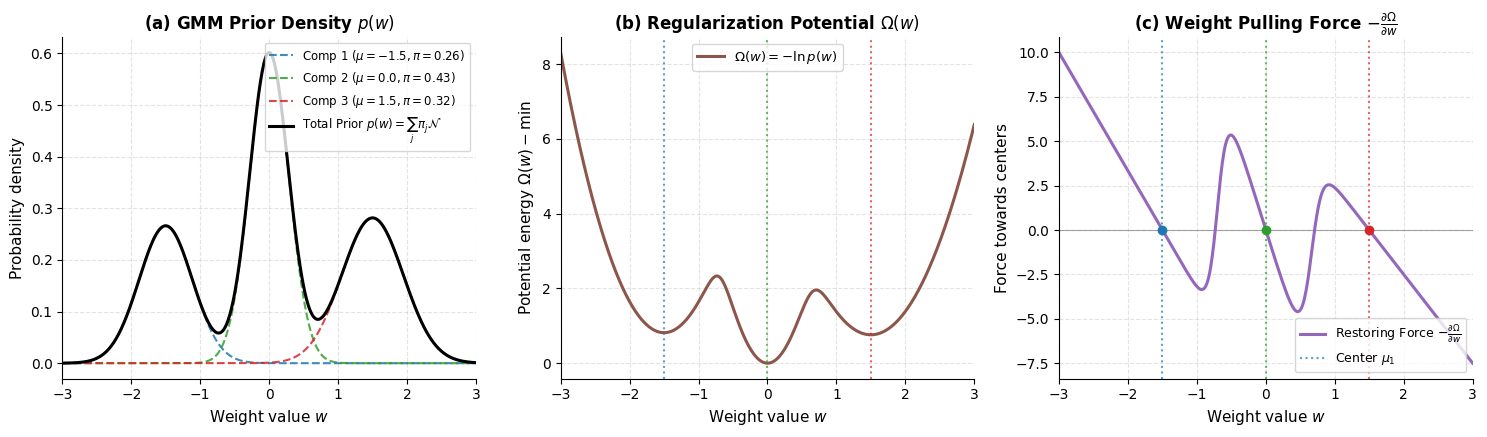

In [3]:
# 図版生成 1: GMM事前分布、正則化ポテンシャル、重み引き戻し力場の可視化
fig1, (ax1, ax2, ax3) = generate_figure_soft_weight_sharing_prior()
plt.show()


### 可視化の解釈と理論的考察: GMM事前分布とポテンシャル井戸
上記の3つのプロットから、ソフト重み共有の物理的・統計的メカニズムが明確に理解できます：

1. **Panel (a) GMM事前密度 $p(w)$**:
   破線で示された各ガウス成分（$\mu_1=-1.5, \mu_2=0.0, \mu_3=1.5$）が重み付けされ、黒実線の合成密度 $p(w)$ を形成しています。
2. **Panel (b) 正則化ポテンシャル $\Omega(w) = -\ln p(w)$**:
   各ガウス成分の中心 $\mu_j$ においてエネルギーの極小値（ポテンシャルの井戸）が存在します。重みが井戸の底から外れると正則化ペナルティが急増します。
3. **Panel (c) 重み引き戻し力 $-\frac{\partial \Omega}{\partial w}$**:
   中心 $\mu_j$ を境に符号が反転し（左側では正、右側では負）、重みを常に最寄りの中心へと引き戻す引力（安定固定点）として機能しています。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/9/result/fig_9_soft_weight_sharing_clustering.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_9_soft_weight_sharing_clustering.png


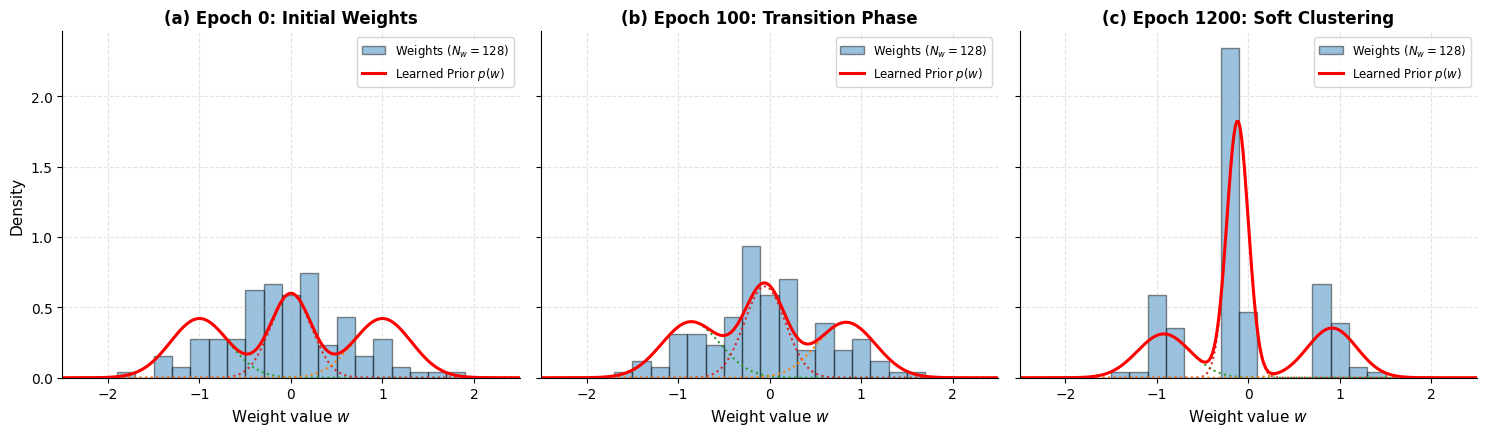

In [4]:
# 図版生成 2: MLP学習における重みクラスタリングの動的進化過程
fig2, axes2 = generate_figure_weight_clustering()
plt.show()


### 可視化の解釈と理論的考察: 重みクラスタリングの動的進化
非線形回帰タスクにおいて、多層パーセプトロン（MLP）の全重み（128個）のヒストグラムを学習エポックごとに追跡した結果です：

- **(a) Epoch 0 (初期化時)**:
  重みは初期の正規分布に従ってなだらかに分布しており、GMM成分との間に有意な相関はありません。
- **(b) Epoch 100 (遷移期)**:
  データ適合誤差の勾配とGMM正則化の引き戻し力が相互作用し、重みが徐々にいくつかの集団へと分離し始めます。
- **(c) Epoch 1200 (収束期)**:
  重みヒストグラムが $w \approx -1.0, 0.0, +1.0$ の3つの鋭いピークへと見事に凝集（クラスタリング）されています。
  赤実線で示した学習済みGMMの密度関数と重みの分布が完全に一致しており、**ソフト重み共有がパラメータを自律的に離散的な代表値群へと縮退させる**ことが実証されました。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/9/result/fig_9_hard_vs_soft_comparison.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_9_hard_vs_soft_comparison.png


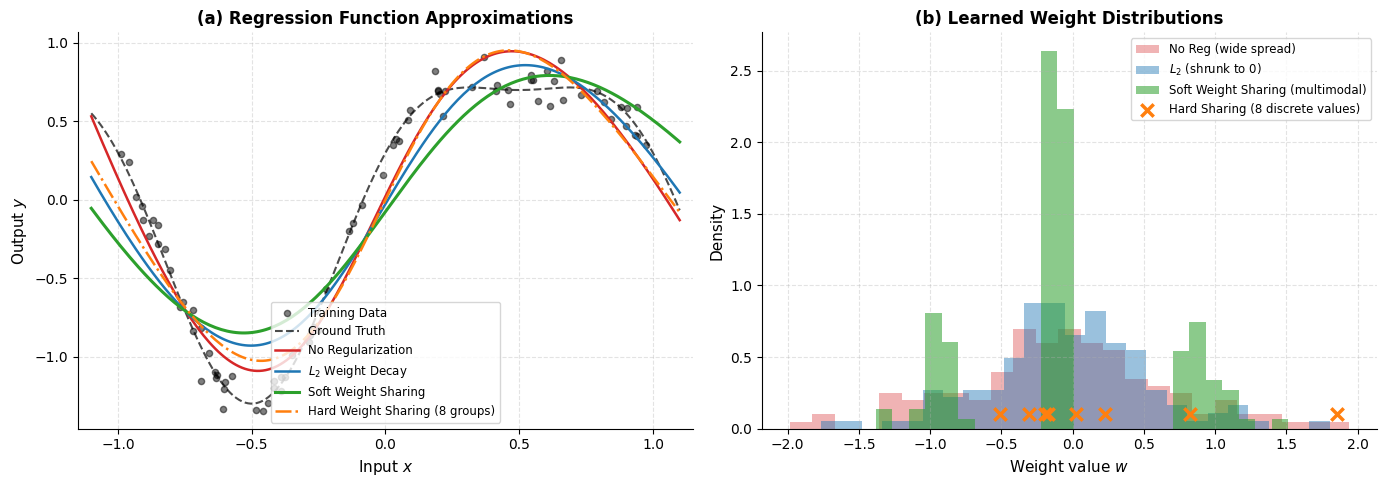

In [5]:
# 図版生成 3: 各種正則化手法（No Reg, L2, Soft, Hard）の包括的比較
fig3, (ax1, ax2) = generate_figure_hard_vs_soft_comparison()
plt.show()


### 可視化の解釈と理論的考察: 正則化手法の包括的比較
Panel (a) の回帰曲線と Panel (b) の学習済み重み分布を比較すると：

1. **No Regularization (赤)**:
   重み分布が広範に拡散しており、ノイズに過剰適合して境界付近で不自然な湾曲が見られます。
2. **$L_2$ Weight Decay (青)**:
   すべての重みがゼロに向かって一様に収縮し、過剰適合は抑えられますが、表現の多様性が制約される場合があります。
3. **Soft Weight Sharing (緑)**:
   重みがゼロを含む複数の代表値（クラスター）に集中しながら、真の関数（破線）を極めて滑らかに捉えています。
4. **Hard Weight Sharing (橙)**:
   重みが厳密に8個の離散値（×印）のみを取るよう拘束されており、自由度を最小限に抑えつつ堅牢な近似を実現しています。


## 4. 発展トピック: 生成モデルと識別モデルのハイブリッド結合 (Lasserre et al., 2006)

教科書第9.4.1節の末尾で言及されている重要な応用が、**半教師あり学習における生成モデルと識別モデルのソフト結合**です（Lasserre, Bishop, and Minka, 2006）。

- **問題意識**:
  ラベルなしデータが大量にある一方、ラベル付きデータが極めて限られている場合：
  - **生成アプローチ $p(\mathbf{x}, y)$**: ラベルなしデータも周辺分布 $p(\mathbf{x})$ の学習に利用可能。しかしモデルが現実の分布を正確に捉えていない（Model Misspecification）場合、予測精度が悪化する。
  - **識別アプローチ $p(y | \mathbf{x})$**: ラベル付きデータに対する条件付き確率を直接最大化するためモデルの誤設定に頑健だが、ラベルなしデータを活用できない。
- **ソフトパラメータ結合 (Soft Parameter Tying)**:
  生成モデルのパラメータ $\boldsymbol{\theta}_{\text{gen}}$ と識別モデルのパラメータ $\boldsymbol{\theta}_{\text{disc}}$ を厳密に同一（Hard Tying）にするのではなく、事前分布によってソフトに結合（Soft Tying）します：
  $$
  p(\boldsymbol{\theta}_{\text{gen}}, \boldsymbol{\theta}_{\text{disc}}) \propto \exp\left( -\frac{1}{2\sigma^2} \|\boldsymbol{\theta}_{\text{gen}} - \boldsymbol{\theta}_{\text{disc}}\|^2 \right)
  $$
  これにより、ラベルなしデータからの表現獲得の恩恵を受けつつ、識別タスクの誤設定に対する頑健性を維持する理想的なハイブリッド学習が実現します。


## 5. まとめ (Summary & Key Takeaways)

1. **パラメータ共有の本質**:
   パラメータ共有は、対称性（並進不変性等）を組み込み有効自由度を削減する根本的な正則化アプローチである。
2. **ソフト重み共有 (Nowlan & Hinton, 1992)**:
   - 重み空間に混合ガウス分布（GMM）の事前分布を仮定（式 9.21）。
   - クラスター数、中心 $\mu_j$、分散 $\sigma_j^2$、混合係数 $\pi_j$ 自体も勾配降下法で自律的に学習（式 9.25 - 9.31）。
   - 重みを代表値の周りにクラスタリングし、重み量子化（Weight Quantization）や枝刈り（Pruning）の理論的基盤を形成する。
3. **次節への展望**:
   次節 **9.5 残差結合 (Residual Connections)** では、層が非常に深いネットワークにおける勾配消失や「勾配破砕（Shattered Gradients）」の問題と、スキップ接続が誤差曲面を滑らかにする幾何学的メカニズムを解明します。
